# Runge-Kutta

# 1. Beskrivning av område
## 1.1 Inledning
I detta projektarbete undersöks numeriska metoder för att lösa ordinära differentialekvationer med hjälp av programmering i Python i en Jupyter Notebook. Fokus ligger på Euler-metoden och dess vidareutveckling, Runge–Kutta-metoden.

Många fysikaliska, tekniska och matematiska problem kan beskrivas med differentialekvationer, men ofta går de inte att lösa exakt analytiskt. Därför används numeriska metoder för att approximera lösningar.

Projektets syfte är att jämföra hur noggranna och effektiva olika metoder är vid lösning av differentialekvationer.

## 1.2 Teori
### Differentialekvationer
En ordinär differentialekvation beskriver sambandet mellan en funktion och dess derivata.

Allmän form:
$$\frac{dy}{dx}=f(x,y)$$
Här beskriver funktionen f(x,y) hur lösningen förändras.
<br>
För att kunna bestämma en specifik lösning används ofta ett begynnelsevillkor:
$$y(x_0)=y_0$$

## 1.3 Euler-metoden
Euler-metoden är den enklaste numeriska metoden för att approximera lösningar till differentialekvationer.
<br>
Metoden bygger på tangentens lutning i varje punkt. Nästa värde beräknas genom att ta ett litet steg framåt i x-led.
<br>
Formeln för Euler-metoden är:
$$y_{n+1}=y_n+h f(x_n,y_n)$$
<br>
där:
<ul>
    <li>$h=$ steglängd</li>
    <li>$x_n=$ nuvarande punkt</li>
    <li>$y_n=$ nuvarande approximation</li>
    <li>$f(x_n,y_n)=$ lutningen i punkten</li>
</ul>
Fördelar
<ul>
    <li>Enkel att förstå och implementera i Python</li>
    <li>Snabb för enkla problem</li>
</ul>

Nackdelar
<ul>
    <li>Ger ofta stora fel</li>
    <li>Kräver små steglängder för hög noggrannhet</li>
</ul>

## 1.4 Runge–Kutta-metoden (RK4)
Runge–Kutta-metoden är en förbättring av Euler-metoden. Den mest använda varianten är fjärde ordningens Runge–Kutta, ofta kallad RK4.
<br>
<br>
Istället för att bara använda en lutning beräknas flera lutningar inom varje steg och kombineras till ett bättre medelvärde.
<br>
<br>
Formlerna är:
$$k_1=f(x_n,y_n)$$
$$k_2=f(x_n+\frac{h}{2},y_n+\frac{h}{2}k_1)$$
$$k_3=f(x_n+\frac{h}{2},y_n+\frac{h}{2}k_2)$$
$$k_4=f(x_n+h,y_n+h k_3)$$

Sedan beräknas nästa värde med:
$$y_{n+1} = y_n + \frac{h}{6}(k_1+2 k_2+2 k_3+k_4)$$
<br>
Fördelar
<ul>
    <li>Betydligt högre noggrannhet än Euler-metoden</li>
    <li>Fungerar bra även med större steglängder</li>
</ul>

Nackdelar
<ul>
    <li>Kräver fler beräkningar per steg</li>
    <li>Något mer avancerad att programmera</li>
</ul>

## 1.5 Vad ska undersökas?
I projektet ska följande undersökas:
<ul>
    <li>Hur Euler-metoden fungerar för att approximera lösningar</li>
    <li>Hur Runge–Kutta-metoden förbättrar noggrannheten</li>
    <li>Hur steglängden påverkar resultatet</li>
    <li>Skillnaden mellan exakt lösning och numerisk approximation</li>
    <li>Hur metoderna implementeras i Python i Jupyter Notebook</li>
</ul>
Projektet kommer även att innehålla grafer och jämförelser mellan metoderna för att analysera fel och precision.

# 2 Modell och simuleringar

### Testdata hämtades från Kunskapsmatrisen!

## importera numpy och matplotlib som libary

In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Funktioner och deras parametrar

In [3]:
# deff ekvationen 
def f(x, y):
    return 4*y+2*(x**2)

# exakta lösningen
def exact_solution(x):
    return (17/16)*np.exp(4*x) - 1/2*(x**2) - 1/4*x - 1/16

# Parametrar
x0, y0 = 0.0, 1.0
x_end = 3.0           # Gemensamt slut-x för jämförelse, fick reda på att vid vissa funktioner som e^(4*12) leder till float overflow error!
steglangder = [1.0, 0.5, 0.1]

### Euler och rk4 approximationer

In [4]:
# Euler-metoden
def euler(f, x0, y0, h):
    #n användes för att veta hur många gånger ska for loop repetera för att x0 ska nå x_end
    n = int((x_end-x0)/h)

    # skappar en array med numpy som innehåller decimaller och är n+1 lång
    x = np.zeros(n+1)
    
    # skappar en array med numpy som innehåller decimaller och är n+1 lång
    y = np.zeros(n+1)

    #sätter in x0 som första värdet i array av x 
    x[0] = x0

    #sätter in y0 som första värdet i array av y 
    y[0] = y0

    #kör en for loop där i plussas med 1 varje gång det repeteras tills det når n och i börjar med värdet 0
    for i in range(n):
        #sparar nästa array i y array. till exempel y[1] = y[0]+ steglängden * f(x0, y0)
        y[i+1] = y[i] + h * f(x[i], y[i])

        #sparar nästa array i x array. till exempel x[1] = x0 + steglängden
        x[i+1] = x[i] + h

    #returnar x och y array
    return x, y

# RK4-metoden
def rk4(f, x0, y0, h):
    #n användes för att veta hur många gånger ska for loop repetera för att x0 ska nå x_end
    n = int((x_end-x0)/h)

    # skappar en array med numpy som innehåller decimaller och är n+1 lång
    x = np.zeros(n+1)

    # skappar en array med numpy som innehåller decimaller och är n+1 lång
    y = np.zeros(n+1)

    #sätter in x0 som första värdet i array av x
    x[0] = x0

    #sätter in y0 som första värdet i array av y 
    y[0] = y0

    #kör en for loop där i plussas med 1 varje gång det repeteras tills det når n och i börjar med värdet 0
    for i in range(n):
        #det sparar variabler k1,k2,k3 och k4 där deras värdet beror på f(x[i], y[i]) och steglängden
        k1 = f(x[i], y[i])
        k2 = f(x[i] + h/2, y[i] + h/2 * k1)
        k3 = f(x[i] + h/2, y[i] + h/2 * k2)
        k4 = f(x[i] + h, y[i] + h * k3)

        #sparar nästa y[i+1] i array y. till exempel y[1] = y0 + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        y[i+1] = y[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

        #sparar nästa array i x array. till exempel x[1] = x0 + steglängden
        x[i+1] = x[i] + h
        
    #returnar x och y array
    return x, y



### Insättning av parametrar i stegmetoder

In [5]:
# Beräknar approximationer med Eulers metod för tre olika steglängder
# steglangder[0] = 1.0, steglangder[1] = 0.5, steglangder[2] = 0.1

# Anropar Euler-metoden med den längsta steglängden (1.0)
x10_eu, y10_eu = euler(f, x0, y0, steglangder[0]) 

# Anropar Euler-metoden med den mellersta steglängden (0.5)
x5_eu, y5_eu = euler(f, x0, y0, steglangder[1]) 

# Anropar Euler-metoden med den kortaste steglängden (0.1)
x1_eu, y1_eu = euler(f, x0, y0, steglangder[2]) 


# Beräknar approximationer med Runge-Kutta 4 (RK4) för samma tre steglängder

# Anropar RK4-metoden med den längsta steglängden (1.0)
x10_rk, y10_rk = rk4(f, x0, y0, steglangder[0]) 

# Anropar RK4-metoden med den mellersta steglängden (0.5)
x5_rk, y5_rk = rk4(f, x0, y0, steglangder[1]) 

# Anropar RK4-metoden med den kortaste steglängden (0.1)
x1_rk, y1_rk = rk4(f, x0, y0, steglangder[2]) 


### Ritning av grafter baserat på arrayer vi har skapat

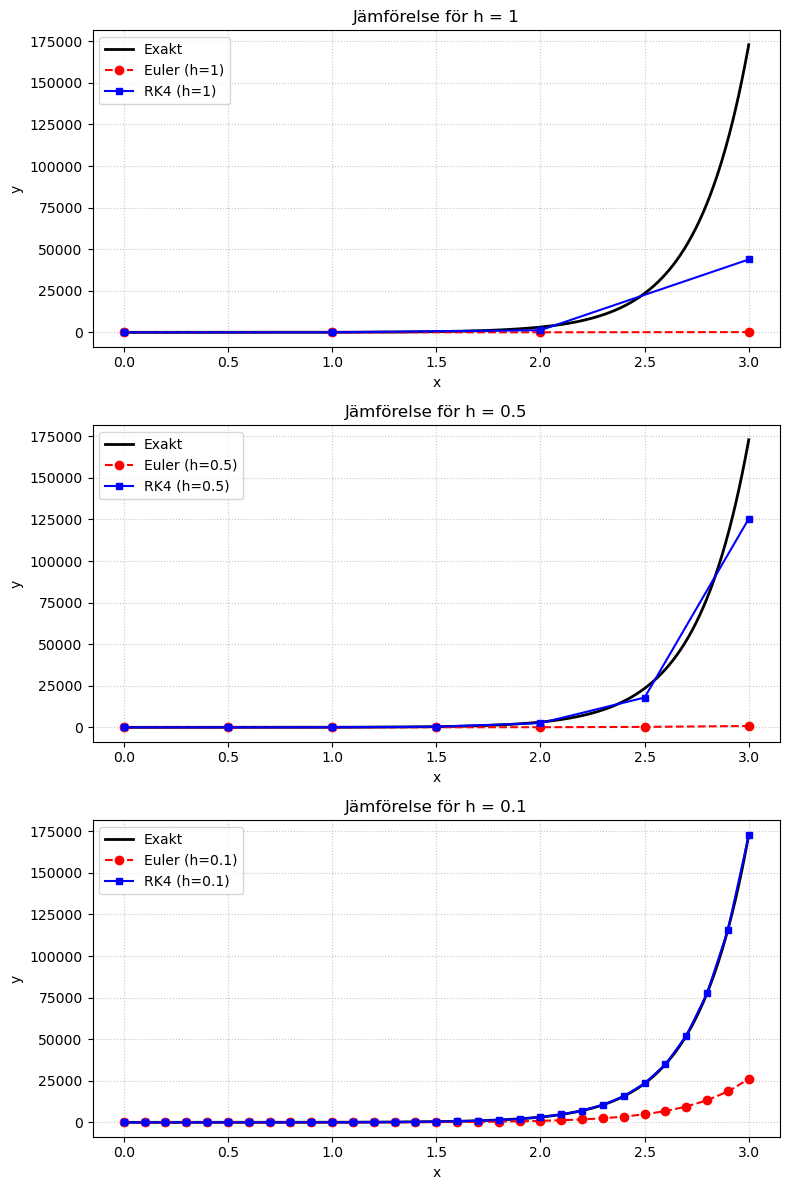

In [6]:
# tar x0 och x_end och delar distansen mellan med 1000 punkter. Punkterna används för att rita en perfekt graf för den exakta lösningen.
# Desto fler punkter desto mer exakt blir grafen men det längre tid det tar för att räkna.
x_fine = np.linspace(x0, x_end, 1000)
#Räknar ut det y värdet för varje av de 1000 x kordinater vi fick fram.
y_exact_fine = exact_solution(x_fine)

#ritar ut graferna på tre olika rader med en kolumn. och figsize är hur stor de graferna visas. 
fig, axes = plt.subplots(3, 1, figsize=(8, 12))  

# Graf 1: h = 1.0 (x10_eu vs x10_rk)

# Välj den första grafen i figuren att rita i
ax = axes[0]

# Rita den exakta lösningen som en tjock, svart, heldragen linje
ax.plot(x_fine, y_exact_fine, "k-", linewidth=2, label="Exakt")

# Rita Eulers metod med röda, streckade linjer och runda prickar
ax.plot(x10_eu, y10_eu, "ro--", linewidth=1.5, markersize=6, label="Euler (h=1)")

# Rita Runge-Kutta 4 med blå, heldragna linjer och fyrkantiga prickar
ax.plot(x10_rk, y10_rk, "bs-", linewidth=1.5, markersize=5, label="RK4 (h=1)")

# Döp den vågräta axeln till "x"
ax.set_xlabel("x")

# Döp den lodräta axeln till "y"
ax.set_ylabel("y")

# Sätt rubriken högst upp på grafen
ax.set_title("Jämförelse för h = 1")

# Lägg till ett diskret, prickigt rutnät i bakgrunden
ax.grid(True, linestyle=":", alpha=0.7)

# Visa rutan med färgförklaringarna
ax.legend()


# Graf 2: h = 0.5 (x5_eu vs x5_rk)
ax = axes[1]
ax.plot(x_fine, y_exact_fine, 'k-', linewidth=2, label='Exakt')
ax.plot(x5_eu, y5_eu, 'ro--', linewidth=1.5, markersize=6, label='Euler (h=0.5)')
ax.plot(x5_rk, y5_rk, 'bs-', linewidth=1.5, markersize=5, label='RK4 (h=0.5)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Jämförelse för h = 0.5')
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

# Graf 3: h = 0.1 (x1_eu vs x1_rk)
ax = axes[2]
ax.plot(x_fine, y_exact_fine, 'k-', linewidth=2, label='Exakt')
ax.plot(x1_eu, y1_eu, 'ro--', linewidth=1.5, markersize=6, label='Euler (h=0.1)')
ax.plot(x1_rk, y1_rk, 'bs-', linewidth=1.5, markersize=5, label='RK4 (h=0.1)')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Jämförelse för h = 0.1')
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend()

plt.tight_layout()
plt.show()

# 3. Resultatdiskussion
En analytisk (exakt) lösning till differentialekvationen togs fram för att generera testdata. Differentialekvationen $y' = 4y+2x^2$ med begynnelsevillkoret $x_0=0, y_0=1$ har den exakta lösningen:

$$y(x) = \frac{17}{16}e^{4x} - \frac{1}{2}x^2 - \frac{1}{4}x - \frac{1}{16}$$

Denna funktion växer mycket snabbt (exponentiellt) på det valda intervallet. Simuleringarna jämför Eulers metod (av första ordningen) och fjärde ordningens Runge–Kutta (RK4) för tre olika steglängder: $h=1.0$, $h=0.5$ och $h=0.1$.

### Steglängden $h=1.0$
Vid den största steglängden $h=1.0$ syns en enorm skillnad mellan metoderna. Euler-lösningen avviker kraftigt och ser nästan helt platt ut i förhållande till den exakta kurvan, eftersom felet ackumuleras extremt snabbt efter bara några få steg. Även RK4 underskattar kurvan kraftigt vid denna grova steglängd, men ligger betydligt närmare än Euler.

### Steglängden $h=0.5$
När steglängden halveras till $h=0.5$ uppvisar Euler-metoden fortfarande ett mycket stort fel och har svårt att hänga med i den exponentiella tillväxten. RK4-metoden förbättras däremot kraftigt och börjar nu närma sig den exakta lösningens form på ett mycket tydligare sätt.

### Steglängden $h=0.1$
Vid den minsta steglängden $h=0.1$ börjar Euler-metoden slutligen att böja av uppåt och följa trenden hos den exakta lösningen. Den är dock fortfarande mindre noggrann än vad RK4 var vid $h=1.0$. För RK4 innebär $h=0.1$ en enorm förbättring, och metoden följer nu den exakta kurvan visuellt perfekt.

## Slutsats
För att nå samma felmarginal som RK4 med $h=1.0$ skulle Euler kräva en steglängd som är långt under $0.1$. Detta skulle kräva enormt många fler steg totalt sett – trots att RK4 gör fyra funktionsberäkningar per enskilt steg.

Slutsatsen är att RK4 ger mycket hög noggrannhet redan vid måttliga steglängder och är det självklara valet för praktiska beräkningar, medan Eulers metod främst har ett pedagogiskt värde. Genom att minska steglängden närmar sig även Euler den exakta lösningen, men den kräver så små steg att den blir helt oekonomisk för krävande tillämpningar.


# 5. Diskussion om användande av AI

Jag använde AI mest för att ta reda på hur Eulers metod och RK4 fungerar och för att få bakgrundsinformation om dem. Det användes också för att bearbeta språket. Genom att låta AI göra den första research fick jag mer tid över till att skriva själva koden. Eftersom jag programmerade metoderna helt på egen hand, utan att AI genererade någon programkod, blev jag tvungen att verkligen förstå steg för steg hur metoderna räknar. Det gjorde att jag lärde mig metoderna mycket bättre än om jag bara hade kopierat färdig kod. 